In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(
    "../data/outs/0322/all_pin.csv",
    engine="python",      # parser mais tolerante
    on_bad_lines="skip"   # ignora linhas inválidas
)
print(df.shape)
df.head()

(70, 60)


,input,fila,n,m,c,CMP,TEST,JZ,JNZ,JL,...,POP,XCHG,TZCNT,LZCNT,BSF,BSR,PREFETCHT0,PREFETCHT1,PREFETCHT2,PREFETCHNTA
0,PIN1,1LVBQ,1000,5000,1000,159604,181113,289347,58565,17881,...,793563,0,0,0,0,0,0,0,0,0
1,PIN1,2LVBQ,1000,5000,1000,157516,164679,288637,55628,19741,...,783746,0,0,0,0,0,0,0,0,0
2,PIN1,3LVBQ,1000,5000,1000,167253,164781,297772,61290,22137,...,804178,0,0,0,0,0,0,0,0,0
3,PIN1,4LVBQ,1000,5000,1000,177514,167000,313758,64682,23134,...,835182,0,0,0,0,0,0,0,0,0
4,PIN1,5LVBQ,1000,5000,1000,182409,167563,316693,64582,25453,...,834728,0,0,0,0,0,0,0,0,0


In [3]:
df["n"] = pd.to_numeric(df["n"], errors="coerce")
df["CMP"] = pd.to_numeric(df["CMP"], errors="coerce")

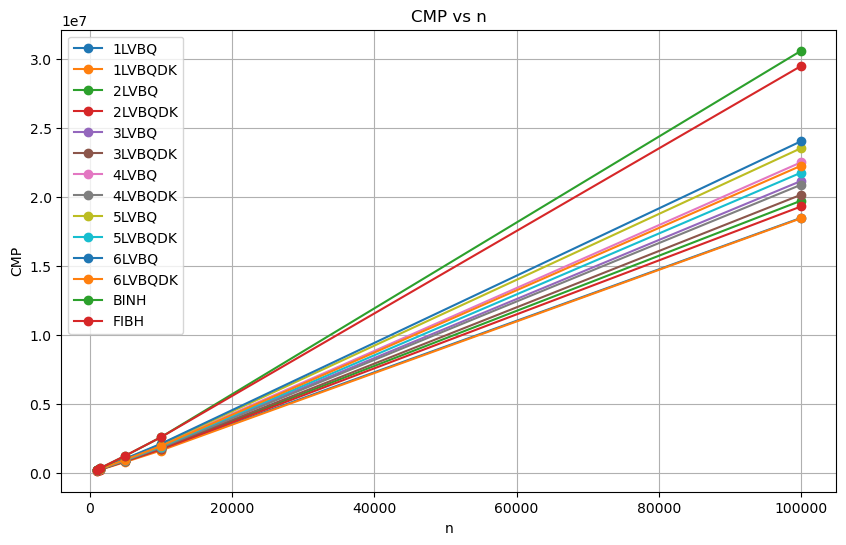

In [4]:

plt.figure(figsize=(10, 6))

# 🔹 Linhas dos dados (uma por fila)
for fila, grupo in df.groupby("fila"):
    grupo = grupo.sort_values("n")
    plt.plot(grupo["n"], grupo["CMP"], marker="o", label=fila)

plt.xlabel("n")
plt.ylabel("CMP")
plt.title("CMP vs n")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
instr_cols = df.columns[5:]  # todas as instruções
df["TOTAL"] = df[instr_cols].sum(axis=1)

In [6]:
branch_cols = [c for c in df.columns if c.startswith("J") or c in ["CALL_NEAR", "RET_NEAR"]]
df["BRANCHES"] = df[branch_cols].sum(axis=1)

In [7]:
mem_cols = ["MOV", "PUSH", "POP", "LEA", "MOVZX", "MOVSXD"]
df["MEMORY_OPS"] = df[mem_cols].sum(axis=1)

In [8]:
# arith_cols = ["ADD", "SUB", "XOR", "AND", "SHL", "SHR", "SAR", "NEG"]
# df["ARITH_OPS"] = df[arith_cols].sum(axis=1)

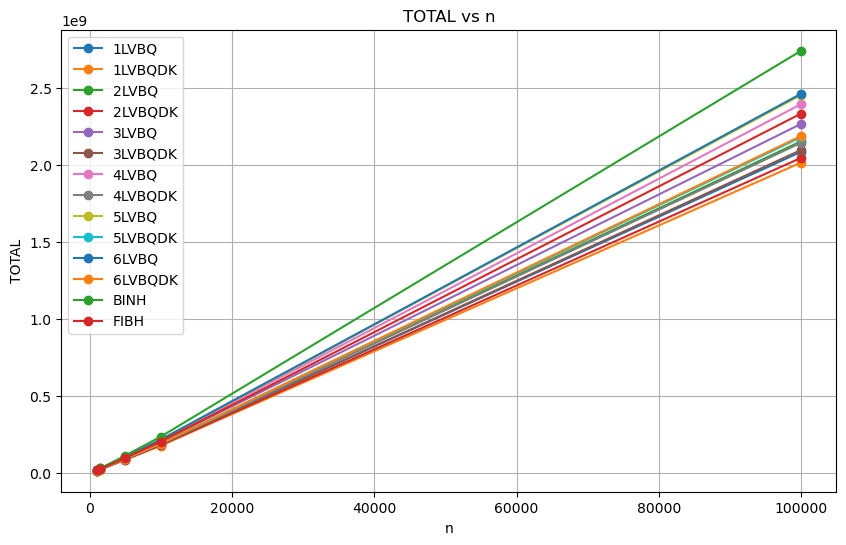

In [9]:

plt.figure(figsize=(10, 6))

# 🔹 Linhas dos dados (uma por fila)
for fila, grupo in df.groupby("fila"):
    grupo = grupo.sort_values("TOTAL")
    plt.plot(grupo["n"], grupo["TOTAL"], marker="o", label=fila)

plt.xlabel("n")
plt.ylabel("TOTAL")
plt.title("TOTAL vs n")
plt.legend()
plt.grid(True)

plt.show()